# TSMC: ARIMA and ARIMAX forecasting experiments

**Objective:** compare next-trading-day closing-price forecasts from an all-usable-feature ARIMAX, a curated-feature ARIMAX, and a close-only ARIMA. Select the best converged configuration on chronological validation data, evaluate it on a reserved test period, and save the model and its preprocessing.

The eventual project objective is profitability. Forecast accuracy is the objective **in this notebook only**; it cannot establish which trading strategy will be most profitable. Trading and transaction-cost simulation are deferred.

## What this notebook contains
1. Data and feature-availability checks.
2. Identical chronological splits and forecast dates for every model.
3. Training-only exploratory plots and stationarity diagnostics.
4. The same ARIMA order grid for all three configurations.
5. One-step walk-forward validation, with a persistence baseline.
6. Validation-based selection, final test evaluation, and error plots.
7. Saved models, preprocessing, predictions, metrics, and an experiment manifest.

**ARIMA versus ARIMAX.** Ordinary ARIMA uses the target's history. Adding explanatory variables through `exog` creates regression with ARIMA errors, often called ARIMAX. Here, `Close[t+1]` is paired with `features[t]`, so tomorrow's unknown OHLCV values are never required. The target remains the unadjusted closing price in USD.

**Provenance:** `features.ipynb` builds the master CSV from `Data/tsm_yfinance_data.csv`; `validate.ipynb` compares it with `Data/google_data.csv`. These local files document Yahoo and Google, not a Nasdaq download. Vendor agreement is useful evidence but is not independent verification of every record. Record the original download URL/method and download date in the project report.

References: [Statsmodels ARIMA](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html), [ARIMA/SARIMAX regression explanation](https://www.statsmodels.org/stable/examples/notebooks/generated/statespace_sarimax_faq.html), [time-series forecasting and state updates](https://www.statsmodels.org/stable/examples/notebooks/generated/statespace_forecasting.html).


## 1. Imports and reproducible configuration

Run the notebook from the project directory (or a child directory). Paths are discovered relative to the project, without hard-coded drive letters. Required packages are `numpy`, `pandas`, `matplotlib`, `scipy`, `scikit-learn`, `statsmodels`, `joblib`, and Jupyter/IPython.

`ORDER_GRID` is applied unchanged to every feature configuration. It includes the existing seven orders and the useful `(0,1,0)` random-walk reference. We investigate first differencing using training-only diagnostics below; the prespecified experiment fixes `d=1` across candidates. `p` is the autoregressive order, `d` the differencing order, and `q` the moving-average error order. We use no deterministic drift (`trend='n'`) for an equally specified comparison.

For practical runtime, parameters are fitted once at each split origin. After each one-step forecast, the newly observed actual value updates the state, **without re-estimating coefficients**. This is an expanding-information walk-forward protocol, not a daily expanding-window parameter refit. Every configuration uses this same protocol. A future refitting-frequency experiment should be selected using validation data.


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import time
import warnings
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import statsmodels
from IPython.display import display, Markdown
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'Data' / 'TSMC_Master_Features_15Y.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Start Jupyter inside the project containing Data/TSMC_Master_Features_15Y.csv.')
DATA_FILE = ROOT / 'Data' / 'TSMC_Master_Features_15Y.csv'
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
RUN_DIR = ROOT / 'models' / 'arima' / RUN_ID
PLOT_DIR = RUN_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=False)

TRAIN_FRACTION, VALIDATION_FRACTION = 0.70, 0.15
ORDER_GRID = [(0, 1, 0), (1, 1, 0), (0, 1, 1), (1, 1, 1),
              (2, 1, 1), (2, 1, 2), (3, 1, 1), (3, 1, 2)]
MAX_ITER = 250
TREND = 'n'
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.titlesize': 12})
pd.set_option('display.max_columns', 20)

def finish_plot(name):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('Project:', ROOT)
print('Outputs:', RUN_DIR)
print('Candidate fits:', len(ORDER_GRID) * 3)


Project: F:\SEM-7\Time Series Analysis\Project
Outputs: F:\SEM-7\Time Series Analysis\Project\models\arima\20260923T021526961853Z
Candidate fits: 24


## 2. Load and audit the master data

Sort dates, reject duplicate dates and non-finite values, and verify elementary OHLC consistency. Missing values from lag/rolling warm-up are expected; we remove incomplete input rows rather than backfilling from the future. We explicitly check that the master features were calculated with trailing windows and past lags.

**Feature availability:** a forecast is issued after day `t` closes. Day `t` OHLCV and its trailing indicators are then observable. `Date` is an index, not a numeric explanatory variable. `Adj Close` is excluded from both feature experiments because a current historical download may retroactively incorporate later corporate actions; this file does not document point-in-time adjusted values. Thus “all features” means **all usable, causally available numeric features**, with this exclusion disclosed. Raw `Close` and its trailing transforms are available at the forecast origin and are valid inputs for `Close[t+1]`.


In [2]:
raw = pd.read_csv(DATA_FILE)
raw['Date'] = pd.to_datetime(raw['Date'], errors='raise')
raw = raw.sort_values('Date').reset_index(drop=True)
assert raw['Date'].notna().all() and raw['Date'].is_unique, 'Missing or duplicate dates.'
assert raw['Date'].is_monotonic_increasing
numeric_columns = raw.columns.drop('Date').tolist()
raw[numeric_columns] = raw[numeric_columns].apply(pd.to_numeric, errors='raise')
assert not np.isinf(raw[numeric_columns].to_numpy()).any(), 'Infinite data values.'
assert (raw['Close'] > 0).all() and (raw['Volume'] >= 0).all()
tol = 1e-5
assert (raw['High'] + tol >= raw[['Open', 'Close', 'Low']].max(axis=1)).all()
assert (raw['Low'] - tol <= raw[['Open', 'Close', 'High']].min(axis=1)).all()

expected = {
    'Log_Close': np.log(raw['Close']),
    'Return_1D': raw['Close'].pct_change(fill_method=None),
    'Log_Return_1D': np.log(raw['Close']).diff(),
    'High_Low_Range': (raw['High'] - raw['Low']) / raw['Close'],
    'Open_Close_Change': (raw['Close'] - raw['Open']) / raw['Open'],
    'Day_of_Week': raw['Date'].dt.dayofweek,
    'Month': raw['Date'].dt.month, 'Quarter': raw['Date'].dt.quarter,
    'Year': raw['Date'].dt.year,
}
for lag in [1, 2, 3, 5, 10, 20]:
    expected[f'Close_Lag_{lag}'] = raw['Close'].shift(lag)
    expected[f'Return_Lag_{lag}'] = expected['Return_1D'].shift(lag)
for window in [5, 10, 20, 50]:
    expected[f'SMA_{window}'] = raw['Close'].rolling(window).mean()
for window in [5, 10, 20]:
    expected[f'Volatility_{window}'] = expected['Log_Return_1D'].rolling(window).std()
    expected[f'Momentum_{window}D'] = raw['Close'].pct_change(window, fill_method=None)
for name, values in expected.items():
    np.testing.assert_allclose(raw[name], values, rtol=1e-6, atol=1e-8,
                               equal_nan=True, err_msg=f'Feature mismatch: {name}')

audit = pd.DataFrame({'dtype': raw.dtypes.astype(str), 'missing': raw.isna().sum()})
display(audit)
print(f'{len(raw):,} rows; {len(raw.columns)} columns; '
      f"{raw['Date'].min().date()} through {raw['Date'].max().date()}")
print('Verified all engineered columns against causal trailing calculations.')
audit.to_csv(RUN_DIR / 'data_audit.csv')


,dtype,missing
Date,datetime64[ns],0
Open,float64,0
High,float64,0
Low,float64,0
Close,float64,0
Adj Close,float64,0
Volume,int64,0
Log_Close,float64,0
Return_1D,float64,1
Log_Return_1D,float64,1


3,771 rows; 38 columns; 2011-09-12 through 2026-09-10
Verified all engineered columns against causal trailing calculations.


## 3. Feature configurations and target alignment

The curated set is specified **before inspecting validation/test performance**. It favors a compact set of relative price changes, volatility, and trading activity rather than many overlapping price-level indicators. These are hypotheses about useful predictors, not a claim that they must improve forecasts.

| Curated input | Reason for inclusion |
|---|---|
| `Return_1D`, `Return_Lag_1`, `Return_Lag_5` | Recent movement and short-lag dependence |
| `High_Low_Range`, `Open_Close_Change` | Intraday range and directional movement |
| `Volatility_20` | Recent variability |
| `Momentum_5D` | Short-term accumulated movement |
| `Volume` | Trading activity; transformed with `log1p` |

The all-feature experiment may suffer from redundancy and collinearity. We report its training-design condition number and optimizer status. All exogenous columns are standardized using training statistics only; `Volume` receives the same `log1p` transform in both configurations. The close-only model uses no exogenous columns or scaler.

We retain a common set of complete rows for every configuration, including the baseline. `Origin_Date` means the evening the forecast is issued; `Target_Date` is the next observed trading date. Splits use ordered **target dates**. The last row has no known target and is excluded from evaluation, but retained separately for future inference.


,split,rows,first_origin,last_origin,first_target,last_target
0,train,2604,2011-11-18,2022-03-25,2011-11-21,2022-03-28
1,validation,558,2022-03-28,2024-06-14,2022-03-29,2024-06-17
2,test,559,2024-06-17,2026-09-09,2024-06-18,2026-09-10


,Origin_Date,Close,Target_Date,Target_Close
0,2011-11-18,12.66,2011-11-21,12.56
1,2011-11-21,12.56,2011-11-22,12.56
2,2011-11-22,12.56,2011-11-23,12.20
3,2011-11-23,12.20,2011-11-25,12.07
4,2011-11-25,12.07,2011-11-28,12.55


All usable exogenous features: 36
Curated exogenous features: 8
Rows omitted for warm-up or unknown final target: 50


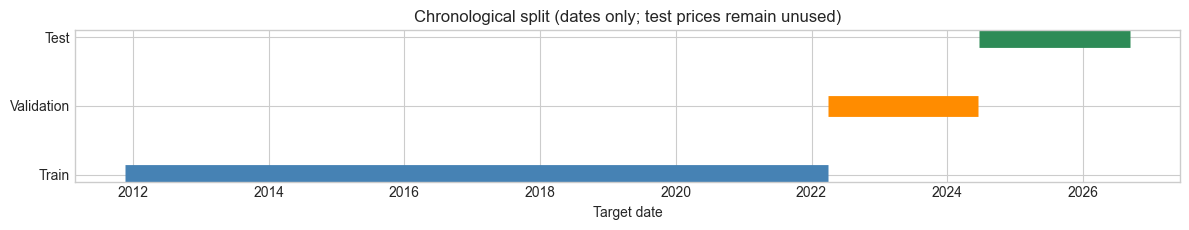

In [3]:
EXCLUDED = {'Date': 'Timestamp/index',
            'Adj Close': 'No point-in-time corporate-action adjustment provenance'}
ALL_FEATURES = [c for c in numeric_columns if c not in EXCLUDED]
CURATED_FEATURES = ['Return_1D', 'Return_Lag_1', 'Return_Lag_5',
                    'High_Low_Range', 'Open_Close_Change', 'Volatility_20',
                    'Momentum_5D', 'Volume']
FEATURE_SETS = {'ARIMAX_all': ALL_FEATURES,
                'ARIMAX_curated': CURATED_FEATURES,
                'ARIMA_close_only': []}

aligned = raw.rename(columns={'Date': 'Origin_Date'}).copy()
aligned['Target_Date'] = aligned['Origin_Date'].shift(-1)
aligned['Target_Close'] = aligned['Close'].shift(-1)
data = aligned.dropna(subset=ALL_FEATURES + ['Target_Date', 'Target_Close']).reset_index(drop=True)
assert len(data) > 500, 'Insufficient complete observations for this experiment.'
assert (data['Origin_Date'] < data['Target_Date']).all()
assert data['Target_Date'].is_unique

n = len(data)
train_end = int(n * TRAIN_FRACTION)
validation_end = int(n * (TRAIN_FRACTION + VALIDATION_FRACTION))
train = data.iloc[:train_end].copy()
validation = data.iloc[train_end:validation_end].copy()
test = data.iloc[validation_end:].copy()
assert train['Target_Date'].max() < validation['Target_Date'].min()
assert validation['Target_Date'].max() < test['Target_Date'].min()
# By each forecast origin, the preceding target has already become observable.
assert train['Target_Date'].iloc[-1] <= validation['Origin_Date'].iloc[0]
assert validation['Target_Date'].iloc[-1] <= test['Origin_Date'].iloc[0]

split_summary = pd.DataFrame([
    {'split': name, 'rows': len(frame),
     'first_origin': frame['Origin_Date'].min(), 'last_origin': frame['Origin_Date'].max(),
     'first_target': frame['Target_Date'].min(), 'last_target': frame['Target_Date'].max()}
    for name, frame in [('train', train), ('validation', validation), ('test', test)]
])
display(split_summary)
display(data[['Origin_Date', 'Close', 'Target_Date', 'Target_Close']].head())
print('All usable exogenous features:', len(ALL_FEATURES))
print('Curated exogenous features:', len(CURATED_FEATURES))
print('Rows omitted for warm-up or unknown final target:', len(raw) - len(data))
split_summary.to_csv(RUN_DIR / 'splits.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 2.4))
for y, (name, frame, color) in enumerate([
        ('Train', train, 'steelblue'), ('Validation', validation, 'darkorange'),
        ('Test', test, 'seagreen')]):
    ax.plot([frame['Target_Date'].min(), frame['Target_Date'].max()], [y, y],
            linewidth=15, solid_capstyle='butt', color=color)
ax.set(yticks=[0, 1, 2], yticklabels=['Train', 'Validation', 'Test'],
       xlabel='Target date', title='Chronological split (dates only; test prices remain unused)')
finish_plot('01_chronological_split')


## 4. Training-only exploratory and stationarity diagnostics

We examine the price series, returns, ACF/PACF of first differences, and feature correlations on training data only. ADF tests a unit-root null; KPSS tests a level-stationarity null. Small ADF p-values support rejecting a unit root, while small KPSS p-values reject level stationarity. Neither test proves forecasting usefulness. Together with the plots, they provide context for first differencing; structural breaks can affect both tests.

These target diagnostics do not establish stationarity of every regression residual in ARIMAX. We separately inspect fitted-model innovations after model selection. ACF/PACF guides interpretation rather than guaranteeing an optimal order.


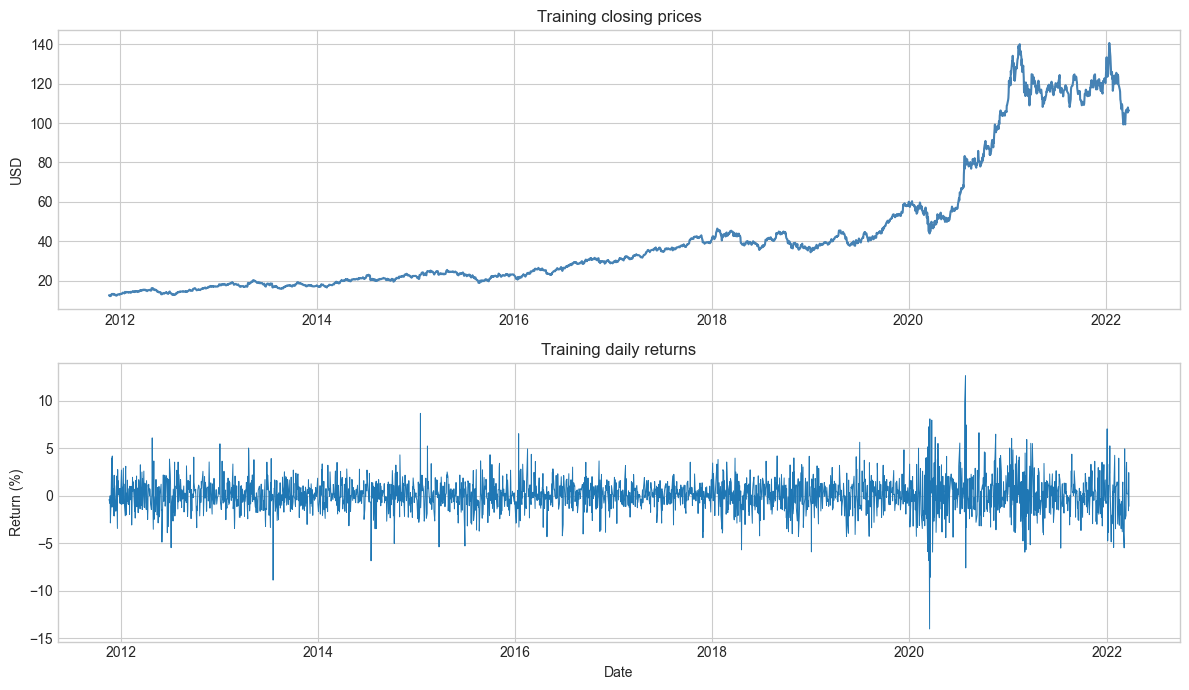

,series,ADF statistic,ADF p,KPSS statistic,KPSS p,KPSS note
0,Close,0.101947,9.661938e-01,6.213305,0.01,The test statistic is outside of the range of ...
1,First difference,-9.407810,5.945936e-16,0.205402,0.10,The test statistic is outside of the range of ...


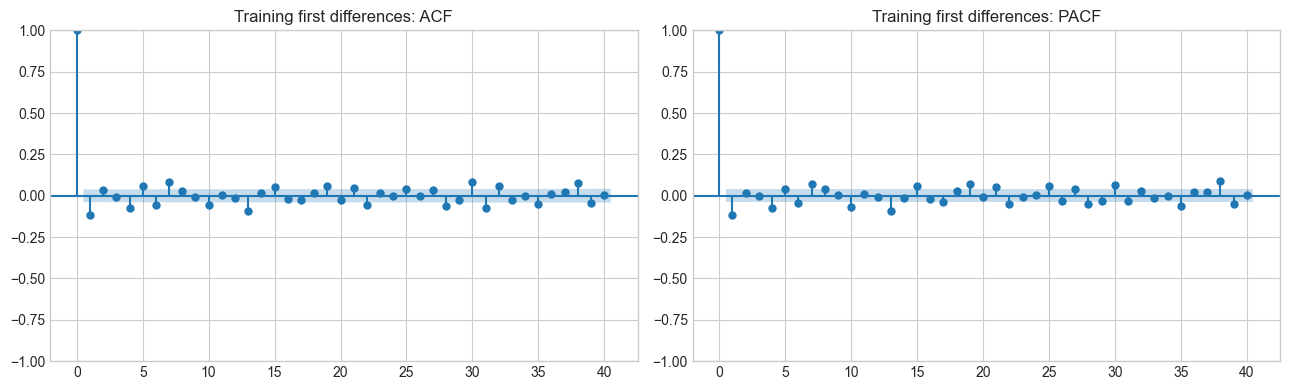

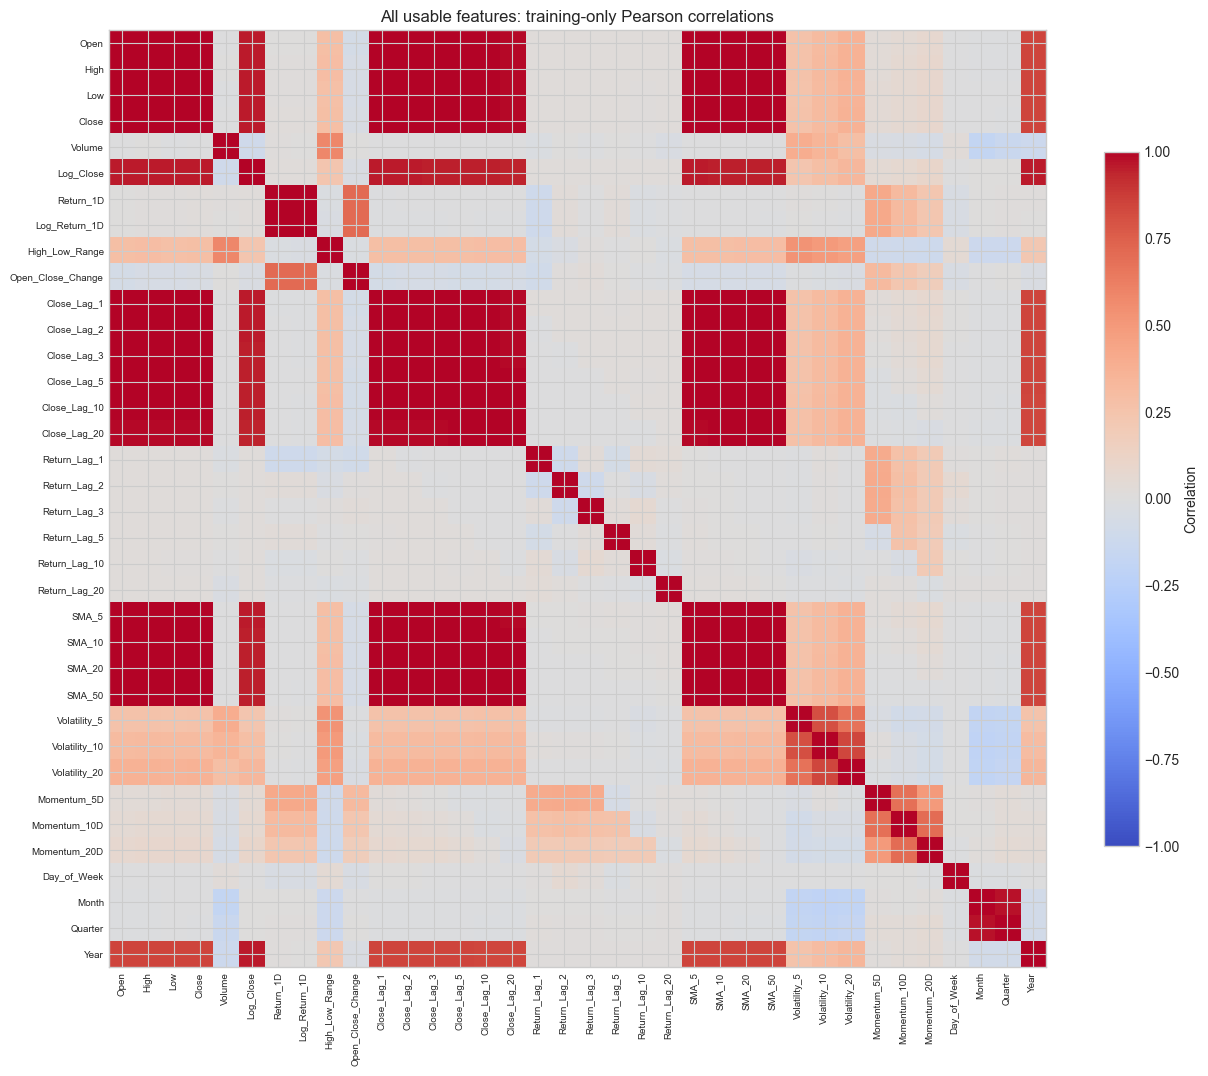

In [4]:
series = train['Target_Close']
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(train['Target_Date'], series, color='steelblue')
axes[0].set(title='Training closing prices', ylabel='USD')
axes[1].plot(train['Origin_Date'], train['Return_1D'] * 100, linewidth=0.7)
axes[1].set(title='Training daily returns', xlabel='Date', ylabel='Return (%)')
finish_plot('02_training_series')

stationarity_rows = []
for label, values in [('Close', series), ('First difference', series.diff().dropna())]:
    adf = adfuller(values, autolag='AIC')
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        kp = kpss(values, regression='c', nlags='auto')
    stationarity_rows.append({'series': label, 'ADF statistic': adf[0], 'ADF p': adf[1],
                             'KPSS statistic': kp[0], 'KPSS p': kp[1],
                             'KPSS note': '; '.join(str(w.message) for w in caught)})
stationarity = pd.DataFrame(stationarity_rows)
display(stationarity)
stationarity.to_csv(RUN_DIR / 'stationarity.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(series.diff().dropna(), lags=40, ax=axes[0])
plot_pacf(series.diff().dropna(), lags=40, method='ywm', ax=axes[1])
axes[0].set_title('Training first differences: ACF')
axes[1].set_title('Training first differences: PACF')
finish_plot('03_training_acf_pacf')

correlations = train[ALL_FEATURES].corr()
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(correlations, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(ALL_FEATURES)), ALL_FEATURES, rotation=90, fontsize=7)
ax.set_yticks(range(len(ALL_FEATURES)), ALL_FEATURES, fontsize=7)
ax.set_title('All usable features: training-only Pearson correlations')
fig.colorbar(im, ax=ax, shrink=0.7, label='Correlation')
finish_plot('04_training_feature_correlations')


## 5. Reusable preprocessing, estimation, and walk-forward evaluation

`prepare_inputs` learns a scaler from the fit period, then applies that exact scaler to the later period. `fit_candidate` fits the ARIMA regression and captures warnings, convergence, AIC/BIC, and elapsed time. Nonconverged candidates remain in the results table but cannot win.

`walk_forward` makes a one-step forecast **before** reading the target into the model state. Only afterward does `extend` incorporate that realized target and its matching exogenous row. Coefficients stay fixed, but the latent ARIMA state evolves as observations arrive. Passing NumPy arrays avoids ambiguous date/index alignment inside Statsmodels; origin and target dates remain explicit in exported tables.

Metrics: MAE is average absolute dollar error; MSE is squared dollar error; RMSE is its square root; MAPE is average percentage error (safe here because prices are positive); R² compares squared error with a constant test-period mean. Direction accuracy compares the sign of the predicted and actual next-day changes from the known origin close. Exact zero changes count as their own direction. MASE divides MAE by the fit-period persistence MAE. Positive RMSE skill means improvement over the persistence baseline on the **same** evaluation dates. R² can be high for persistent prices even when a model fails to beat persistence.


In [5]:
def feature_values(frame, columns):
    values = frame[columns].astype(float).copy()
    if 'Volume' in columns:
        values['Volume'] = np.log1p(values['Volume'])
    return values.to_numpy(dtype=float)

def prepare_inputs(fit_frame, later_frame, columns):
    if not columns:
        return None, None, None
    scaler = StandardScaler()
    x_fit = scaler.fit_transform(feature_values(fit_frame, columns))
    x_later = scaler.transform(feature_values(later_frame, columns))
    assert np.isfinite(x_fit).all() and np.isfinite(x_later).all()
    return x_fit, x_later, scaler

def fit_candidate(y, x, order):
    started = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        fitted = ARIMA(np.asarray(y, dtype=float), exog=x, order=order, trend=TREND,
                       enforce_stationarity=True, enforce_invertibility=True,
                       concentrate_scale=False).fit(
            method='statespace', method_kwargs={'maxiter': MAX_ITER, 'disp': 0},
            cov_type='none')
    convergence = bool(fitted.mle_retvals.get('converged', False))
    messages = list(dict.fromkeys(str(w.message) for w in caught))
    return fitted, convergence, messages, time.perf_counter() - started

def walk_forward(fitted, later_frame, x_later, intervals=False):
    state = fitted
    predictions, lower, upper = [], [], []
    for i in range(len(later_frame)):
        x_next = None if x_later is None else x_later[i:i + 1]
        forecast = state.get_forecast(steps=1, exog=x_next)
        predictions.append(float(np.asarray(forecast.predicted_mean).reshape(-1)[0]))
        if intervals:
            bounds = np.asarray(forecast.conf_int(alpha=0.05)).reshape(-1)
            lower.append(float(bounds[0]))
            upper.append(float(bounds[1]))
        # Observe the realization only AFTER producing its forecast.
        observed = float(later_frame['Target_Close'].iloc[i])
        state = state.extend(endog=np.array([observed]), exog=x_next)
    predictions = np.asarray(predictions)
    if not np.isfinite(predictions).all():
        raise ValueError('Non-finite forecasts.')
    return predictions, np.asarray(lower), np.asarray(upper)

def score(frame, predictions, fit_frame):
    actual = frame['Target_Close'].to_numpy(dtype=float)
    origin = frame['Close'].to_numpy(dtype=float)
    predictions = np.asarray(predictions, dtype=float)
    assert actual.shape == predictions.shape and np.isfinite(predictions).all()
    mae = mean_absolute_error(actual, predictions)
    mse = mean_squared_error(actual, predictions)
    baseline_rmse = np.sqrt(mean_squared_error(actual, origin))
    scale = np.mean(np.abs(fit_frame['Target_Close'] - fit_frame['Close']))
    return {'MAE': mae, 'MSE': mse, 'RMSE': np.sqrt(mse),
            'MAPE_pct': np.mean(np.abs((actual - predictions) / actual)) * 100,
            'R2': r2_score(actual, predictions), 'MASE': mae / scale,
            'Direction_accuracy_pct': np.mean(np.sign(predictions - origin) ==
                                               np.sign(actual - origin)) * 100,
            'RMSE_skill_pct': (1 - np.sqrt(mse) / baseline_rmse) * 100}

# A random walk without drift must reproduce persistence in walk-forward mode.
smoke_frame = pd.DataFrame({'Target_Close': [14., 13., 16.]})
smoke_fit, _, _, _ = fit_candidate(np.array([10., 11., 9., 12.]), None, (0, 1, 0))
smoke_predictions, _, _ = walk_forward(smoke_fit, smoke_frame, None)
np.testing.assert_allclose(smoke_predictions, [12., 14., 13.], atol=1e-6)
print('Forecast-before-observe timing check passed.')

design_rows = []
for name, columns in FEATURE_SETS.items():
    if columns:
        x, _, _ = prepare_inputs(train, validation, columns)
        design_rows.append({'configuration': name, 'features': len(columns),
                            'rank': np.linalg.matrix_rank(x),
                            'condition_number': np.linalg.cond(x),
                            'differenced_rank': np.linalg.matrix_rank(np.diff(x, axis=0)),
                            'differenced_condition_number': np.linalg.cond(np.diff(x, axis=0))})
design_diagnostics = pd.DataFrame(design_rows)
display(design_diagnostics)
design_diagnostics.to_csv(RUN_DIR / 'design_diagnostics.csv', index=False)


Forecast-before-observe timing check passed.


,configuration,features,rank,condition_number,differenced_rank,differenced_condition_number
0,ARIMAX_all,36,36,1537.604605,36,945.804627
1,ARIMAX_curated,8,8,2.745344,8,12.843501


## 6. Common-grid chronological validation

Each feature configuration gets exactly the same orders, training targets, validation targets, trend, optimizer limit, and state-update protocol. The persistence baseline predicts `Close[t+1] = Close[t]`.

Model fitting can take several minutes, especially with all explanatory columns. Results and warnings are checkpointed after every candidate. We never silently suppress or select a nonconverged fit. If a whole configuration fails, the table documents that limitation. Hyperparameter changes prompted by validation results are further experimentation and should be reported.


In [6]:
records = []
validation_forecasts = {}
validation_fit_metadata = {}
baseline_validation = score(validation, validation['Close'].to_numpy(), train)
print('Persistence validation RMSE:', round(baseline_validation['RMSE'], 6))

for name, columns in FEATURE_SETS.items():
    x_train, x_validation, _ = prepare_inputs(train, validation, columns)
    for order in ORDER_GRID:
        key = f'{name}__{order[0]}_{order[1]}_{order[2]}'
        print(f'Fitting {key} ...', flush=True)
        row = {'candidate': key, 'configuration': name, 'p': order[0], 'd': order[1],
               'q': order[2], 'n_features': len(columns), 'status': 'failed',
               'converged': False, 'warnings': '', 'error': ''}
        try:
            fitted, converged, messages, seconds = fit_candidate(train['Target_Close'], x_train, order)
            row.update(converged=converged, warnings=' || '.join(messages),
                       fit_seconds=seconds, AIC=fitted.aic, BIC=fitted.bic,
                       n_parameters=len(fitted.params))
            predictions, _, _ = walk_forward(fitted, validation, x_validation)
            row.update(score(validation, predictions, train))
            row['status'] = 'ok' if converged else 'nonconverged'
            validation_forecasts[key] = predictions
            validation_fit_metadata[key] = {'order': order, 'configuration': name}
            print(f"  {row['status']}: RMSE={row['RMSE']:.6f}; fit={seconds:.1f}s", flush=True)
        except Exception as exc:
            row['error'] = f'{type(exc).__name__}: {exc}'
            print(' ', row['error'], flush=True)
        records.append(row)
        pd.DataFrame(records).to_csv(RUN_DIR / 'validation_grid.csv', index=False)

results = pd.DataFrame(records)
display(results.sort_values('RMSE', na_position='last')[[
    'configuration', 'p', 'd', 'q', 'status', 'MAE', 'RMSE', 'MAPE_pct',
    'R2', 'RMSE_skill_pct', 'fit_seconds']])
display(results.loc[(results['status'] != 'ok') | results['warnings'].ne(''),
                    ['candidate', 'status', 'warnings', 'error']])
validation_export = validation[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].copy()
validation_export['Persistence'] = validation['Close'].to_numpy()
for key, predictions in validation_forecasts.items():
    validation_export[key] = predictions
validation_export.to_csv(RUN_DIR / 'validation_predictions.csv', index=False)


Persistence validation RMSE: 2.231658
Fitting ARIMAX_all__0_1_0 ...


  ok: RMSE=2.263289; fit=2.8s


Fitting ARIMAX_all__1_1_0 ...


  nonconverged: RMSE=2.271277; fit=36.7s


Fitting ARIMAX_all__0_1_1 ...


...

  ok: RMSE=2.250391; fit=0.7s


,configuration,p,d,q,status,MAE,RMSE,MAPE_pct,R2,RMSE_skill_pct,fit_seconds
16,ARIMA_close_only,0,1,0,ok,1.607186,2.231658,1.622008,0.990239,0.000000,0.025912
8,ARIMAX_curated,0,1,0,ok,1.618394,2.235412,1.635501,0.990206,-0.168199,0.624328
10,ARIMAX_curated,0,1,1,ok,1.624826,2.243813,1.643145,0.990133,-0.544634,0.909060
9,ARIMAX_curated,1,1,0,ok,1.625994,2.244678,1.644249,0.990125,-0.583389,0.860280
11,ARIMAX_curated,1,1,1,ok,1.626799,2.245074,1.644954,0.990122,-0.601138,1.439051
12,ARIMAX_curated,2,1,1,ok,1.627132,2.245216,1.645175,0.990120,-0.607533,1.157477
14,ARIMAX_curated,3,1,1,ok,1.627160,2.245232,1.645207,0.990120,-0.608237,1.526793
18,ARIMA_close_only,0,1,1,ok,1.622293,2.247021,1.639205,0.990104,-0.688379,0.054001
15,ARIMAX_curated,3,1,2,ok,1.624477,2.248512,1.639940,0.990091,-0.755195,5.160560
17,ARIMA_close_only,1,1,0,ok,1.624683,2.248707,1.641584,0.990090,-0.763949,0.057423


,candidate,status,warnings,error
1,ARIMAX_all__1_1_0,nonconverged,Maximum Likelihood optimization failed to conv...,
2,ARIMAX_all__0_1_1,nonconverged,Maximum Likelihood optimization failed to conv...,
3,ARIMAX_all__1_1_1,nonconverged,Maximum Likelihood optimization failed to conv...,
4,ARIMAX_all__2_1_1,nonconverged,Non-stationary starting autoregressive paramet...,
6,ARIMAX_all__3_1_1,nonconverged,Maximum Likelihood optimization failed to conv...,
7,ARIMAX_all__3_1_2,nonconverged,Non-stationary starting autoregressive paramet...,
12,ARIMAX_curated__2_1_1,ok,Non-stationary starting autoregressive paramet...,


,configuration,p,d,q,status,MAE,RMSE,MAPE_pct,R2,RMSE_skill_pct,fit_seconds
16,ARIMA_close_only,0,1,0,ok,1.607186,2.231658,1.622008,0.990239,0.000000,0.019405
8,ARIMAX_curated,0,1,0,ok,1.618394,2.235412,1.635501,0.990206,-0.168199,0.432489
10,ARIMAX_curated,0,1,1,ok,1.624826,2.243813,1.643145,0.990133,-0.544634,0.660942
9,ARIMAX_curated,1,1,0,ok,1.625994,2.244678,1.644249,0.990125,-0.583389,0.594224
11,ARIMAX_curated,1,1,1,ok,1.626799,2.245074,1.644954,0.990122,-0.601138,0.954961
12,ARIMAX_curated,2,1,1,ok,1.627132,2.245216,1.645175,0.990120,-0.607533,0.815941
14,ARIMAX_curated,3,1,1,ok,1.627160,2.245232,1.645207,0.990120,-0.608237,1.032720
18,ARIMA_close_only,0,1,1,ok,1.622293,2.247021,1.639205,0.990104,-0.688379,0.038954
15,ARIMAX_curated,3,1,2,ok,1.624476,2.248502,1.639938,0.990091,-0.754746,4.414814
17,ARIMA_close_only,1,1,0,ok,1.624683,2.248707,1.641584,0.990090,-0.763949,0.029156


,candidate,status,warnings,error
1,ARIMAX_all__1_1_0,nonconverged,Maximum Likelihood optimization failed to conv...,
2,ARIMAX_all__0_1_1,nonconverged,Maximum Likelihood optimization failed to conv...,
3,ARIMAX_all__1_1_1,nonconverged,Maximum Likelihood optimization failed to conv...,
4,ARIMAX_all__2_1_1,nonconverged,Non-stationary starting autoregressive paramet...,
6,ARIMAX_all__3_1_1,nonconverged,Maximum Likelihood optimization failed to conv...,
7,ARIMAX_all__3_1_2,nonconverged,Non-stationary starting autoregressive paramet...,
12,ARIMAX_curated__2_1_1,ok,Non-stationary starting autoregressive paramet...,


## 7. Select and justify the forecasting model

Selection uses the lowest validation RMSE among converged, finite candidates. Exact ties are broken by MAE, then parameter count, then candidate name for reproducibility. RMSE and MSE give the same ranking; MAE helps identify sensitivity to large errors. AIC/BIC are supporting fit diagnostics, not the selection objective. Small performance differences are descriptive and are not proof of statistical superiority.

The notebook saves the best **ARIMA-family** candidate even if persistence performs better. In that case we explicitly report that the experiment has not demonstrated forecasting improvement. We do not force an ARIMAX model to win or use the test set to select a replacement.


,configuration,p,d,q,RMSE,MAE,R2,RMSE_skill_pct
0,ARIMA_close_only,0,1,0,2.231658,1.607186,0.990239,0.000000
1,ARIMAX_curated,0,1,0,2.235412,1.618394,0.990206,-0.168199
16,ARIMAX_all,0,1,0,2.263289,1.632488,0.989961,-1.417376


,MAE,MSE,RMSE,MAPE_pct,R2,MASE,Direction_accuracy_pct,RMSE_skill_pct
configuration,,,,,,,,
ARIMA_close_only,1.607186,4.980299,2.231658,1.622008,0.990239,2.605615,0.179211,0.000000
ARIMAX_curated,1.618394,4.997067,2.235412,1.635501,0.990206,2.623786,46.236559,-0.168199
ARIMAX_all,1.632488,5.122479,2.263289,1.647964,0.989961,2.646635,48.745520,-1.417376
Persistence,1.607186,4.980299,2.231658,1.622008,0.990239,2.605615,0.179211,0.000000


Selected ARIMA-family model: ARIMA_close_only, order=(0, 1, 0)
Validation RMSE: 2.231658 USD; persistence: 2.231658 USD
Persistence is at least as good on validation. No forecasting improvement is established.


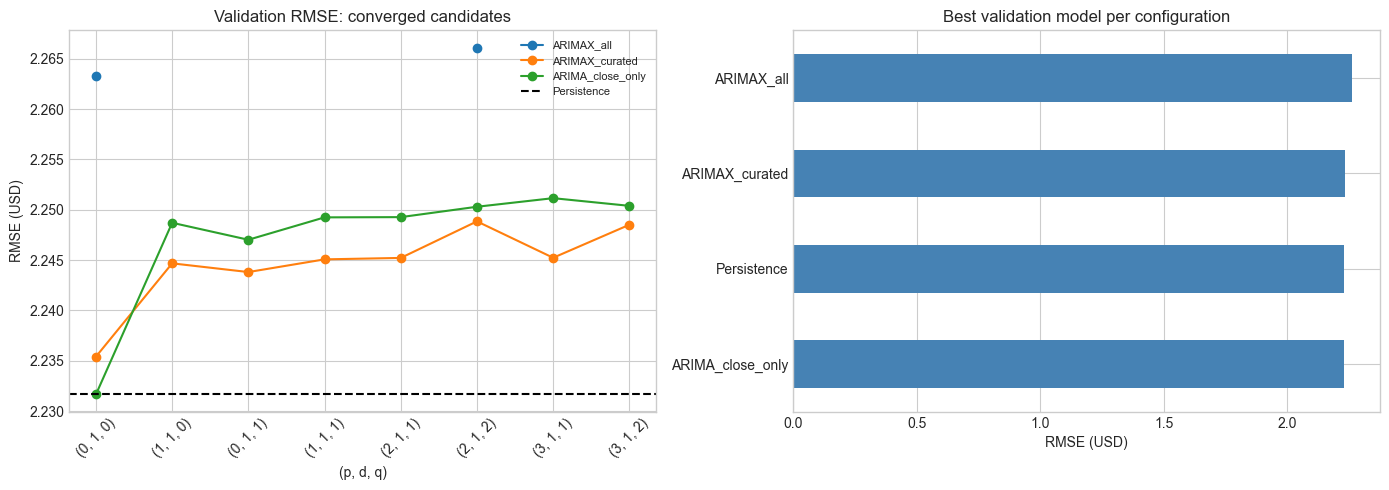

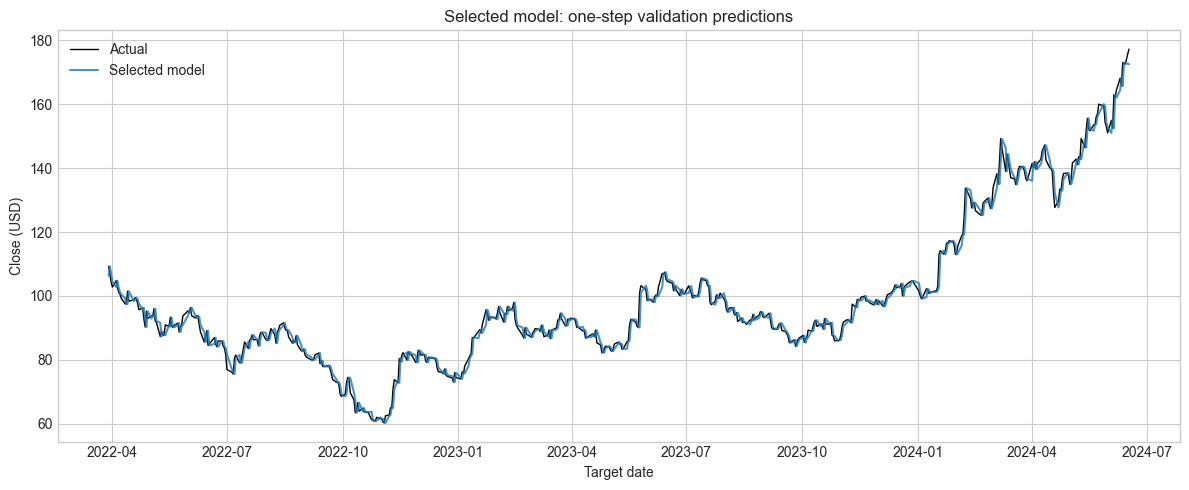

In [7]:
eligible = results.loc[(results['status'] == 'ok') & np.isfinite(results['RMSE'])].copy()
if eligible.empty:
    raise RuntimeError('No eligible model. Inspect validation_grid.csv; do not proceed to test selection.')
ranked = eligible.sort_values(['RMSE', 'MAE', 'n_parameters', 'candidate']).reset_index(drop=True)
best = ranked.iloc[0]
BEST_NAME = str(best['configuration'])
BEST_ORDER = (int(best['p']), int(best['d']), int(best['q']))
BEST_COLUMNS = FEATURE_SETS[BEST_NAME]
BEST_KEY = str(best['candidate'])
family_winners = ranked.groupby('configuration', sort=False).head(1)
display(family_winners[['configuration', 'p', 'd', 'q', 'RMSE', 'MAE', 'R2', 'RMSE_skill_pct']])
comparison = family_winners.set_index('configuration')[['MAE', 'MSE', 'RMSE', 'MAPE_pct',
               'R2', 'MASE', 'Direction_accuracy_pct', 'RMSE_skill_pct']].copy()
comparison.loc['Persistence'] = pd.Series(baseline_validation)
display(comparison)
comparison.to_csv(RUN_DIR / 'validation_best_by_configuration.csv')

print(f'Selected ARIMA-family model: {BEST_NAME}, order={BEST_ORDER}')
print(f"Validation RMSE: {best['RMSE']:.6f} USD; persistence: {baseline_validation['RMSE']:.6f} USD")
if best['RMSE'] >= baseline_validation['RMSE']:
    print('Persistence is at least as good on validation. No forecasting improvement is established.')
else:
    print(f"Validation RMSE improvement over persistence: {best['RMSE_skill_pct']:.3f}%")
for name in FEATURE_SETS:
    if name not in family_winners['configuration'].values:
        print(f'LIMITATION: {name} produced no eligible candidate.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orders = [str(o) for o in ORDER_GRID]
for name in FEATURE_SETS:
    subset = results[results['configuration'] == name]
    values = [subset.loc[(subset['p'] == o[0]) & (subset['d'] == o[1]) &
                        (subset['q'] == o[2]) & (subset['status'] == 'ok'), 'RMSE']
              for o in ORDER_GRID]
    axes[0].plot(orders, [v.iloc[0] if len(v) else np.nan for v in values], marker='o', label=name)
axes[0].axhline(baseline_validation['RMSE'], color='black', linestyle='--', label='Persistence')
axes[0].set(title='Validation RMSE: converged candidates', ylabel='RMSE (USD)', xlabel='(p, d, q)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=8)
comparison['RMSE'].sort_values().plot.barh(ax=axes[1], color='steelblue')
axes[1].set(title='Best validation model per configuration', xlabel='RMSE (USD)', ylabel='')
finish_plot('05_validation_comparison')

fig, ax = plt.subplots()
ax.plot(validation['Target_Date'], validation['Target_Close'], label='Actual', color='black', linewidth=1)
ax.plot(validation['Target_Date'], validation_forecasts[BEST_KEY], label='Selected model', alpha=0.8)
ax.set(title='Selected model: one-step validation predictions', xlabel='Target date', ylabel='Close (USD)')
ax.legend()
finish_plot('06_validation_forecast')


## 8. Refit the locked configuration and diagnose training innovations

After selection, refit the same order and feature list on train + validation, with a newly fitted scaler for that combined historical period. No test targets are used in this fit. If this refit does not converge, stop rather than silently publishing an unreliable model or choosing another using test results.

The residual plots use standardized one-step innovations, dropping the initialization burn-in. Ljung–Box tests check remaining autocorrelation at lags 10 and 20, with degrees of freedom adjusted by `p+q`. Small p-values suggest unmodeled serial dependence. Non-normality or changing variance warns that Gaussian prediction intervals may be poorly calibrated. These diagnostics are reported; they do not trigger test-guided retuning.


Final refit converged: True
Final refit warnings: []


,lb_stat,lb_pvalue
10,47.846076,6.621500e-07
20,99.657572,1.450425e-12


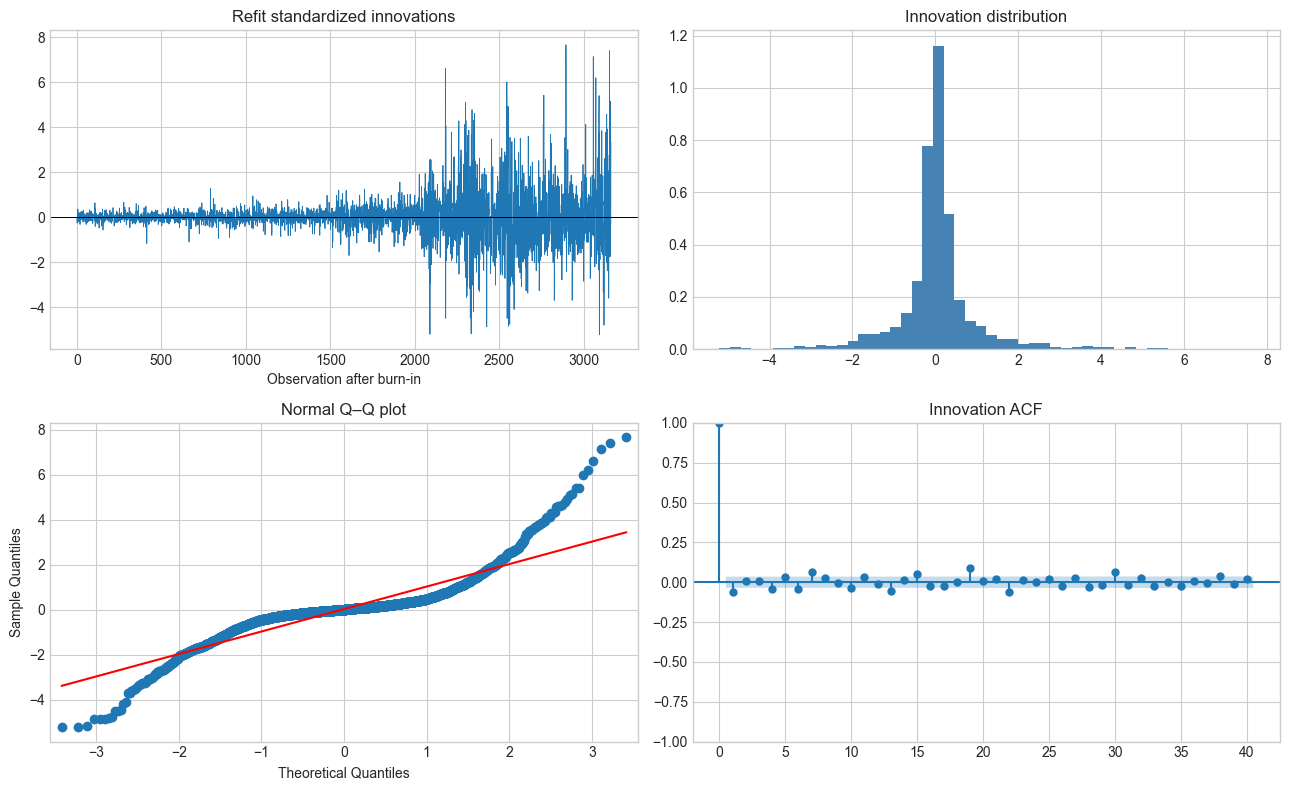

In [8]:
history = pd.concat([train, validation], ignore_index=True)
x_history, x_test, final_scaler = prepare_inputs(history, test, BEST_COLUMNS)
final_model, final_converged, final_warnings, final_fit_seconds = fit_candidate(
    history['Target_Close'], x_history, BEST_ORDER)
print('Final refit converged:', final_converged)
print('Final refit warnings:', final_warnings)
if not final_converged:
    raise RuntimeError('Locked model did not converge on train + validation. Test evaluation stopped.')

burn = max(int(final_model.loglikelihood_burn), max(BEST_ORDER[0], BEST_ORDER[2]) + BEST_ORDER[1], 1)
innovations = np.asarray(final_model.filter_results.standardized_forecasts_error)[0, burn:]
innovations = innovations[np.isfinite(innovations)]
ljung_box = acorr_ljungbox(innovations, lags=[10, 20],
                          model_df=BEST_ORDER[0] + BEST_ORDER[2], return_df=True)
display(ljung_box)
ljung_box.to_csv(RUN_DIR / 'refit_ljung_box.csv')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(innovations, linewidth=0.6)
axes[0, 0].axhline(0, color='black', linewidth=0.7)
axes[0, 0].set(title='Refit standardized innovations', xlabel='Observation after burn-in')
axes[0, 1].hist(innovations, bins=50, density=True, color='steelblue')
axes[0, 1].set_title('Innovation distribution')
qqplot(innovations, line='s', ax=axes[1, 0])
axes[1, 0].set_title('Normal Q–Q plot')
plot_acf(innovations, lags=40, ax=axes[1, 1])
axes[1, 1].set_title('Innovation ACF')
finish_plot('07_refit_residual_diagnostics')


## 9. Reserved test evaluation and forecast plots

Only the locked winner and persistence are evaluated here. The rolling procedure may consume an earlier test actual after forecasting it, because that value would be available at the next forecast origin; it never uses a later actual to forecast an earlier date. We do not select orders, features, or thresholds from test results.

The 95% intervals are conditional model-based intervals from Statsmodels. They do not include all parameter uncertainty and are not a guarantee of coverage. We measure actual test coverage and mean interval width. A 20-observation rolling MAE plot shows whether error varies across periods.

**Existing-project limitation:** the original ARIMA and naïve notebooks already displayed results for part of this historical test period. This is a reproducible held-out evaluation for the current procedure, but cannot honestly be described as a never-before-seen research sample. A later untouched period would be needed for a stronger final confirmation.


,MAE,MSE,RMSE,MAPE_pct,R2,MASE,Direction_accuracy_pct,RMSE_skill_pct
model,,,,,,,,
ARIMA_close_only,5.232576,54.778805,7.40127,1.96797,0.993493,6.61023,0.178891,0.0
Persistence,5.232576,54.778805,7.40127,1.96797,0.993493,6.61023,0.178891,0.0


95% interval empirical coverage: 40.79%
Mean interval width: $5.5286


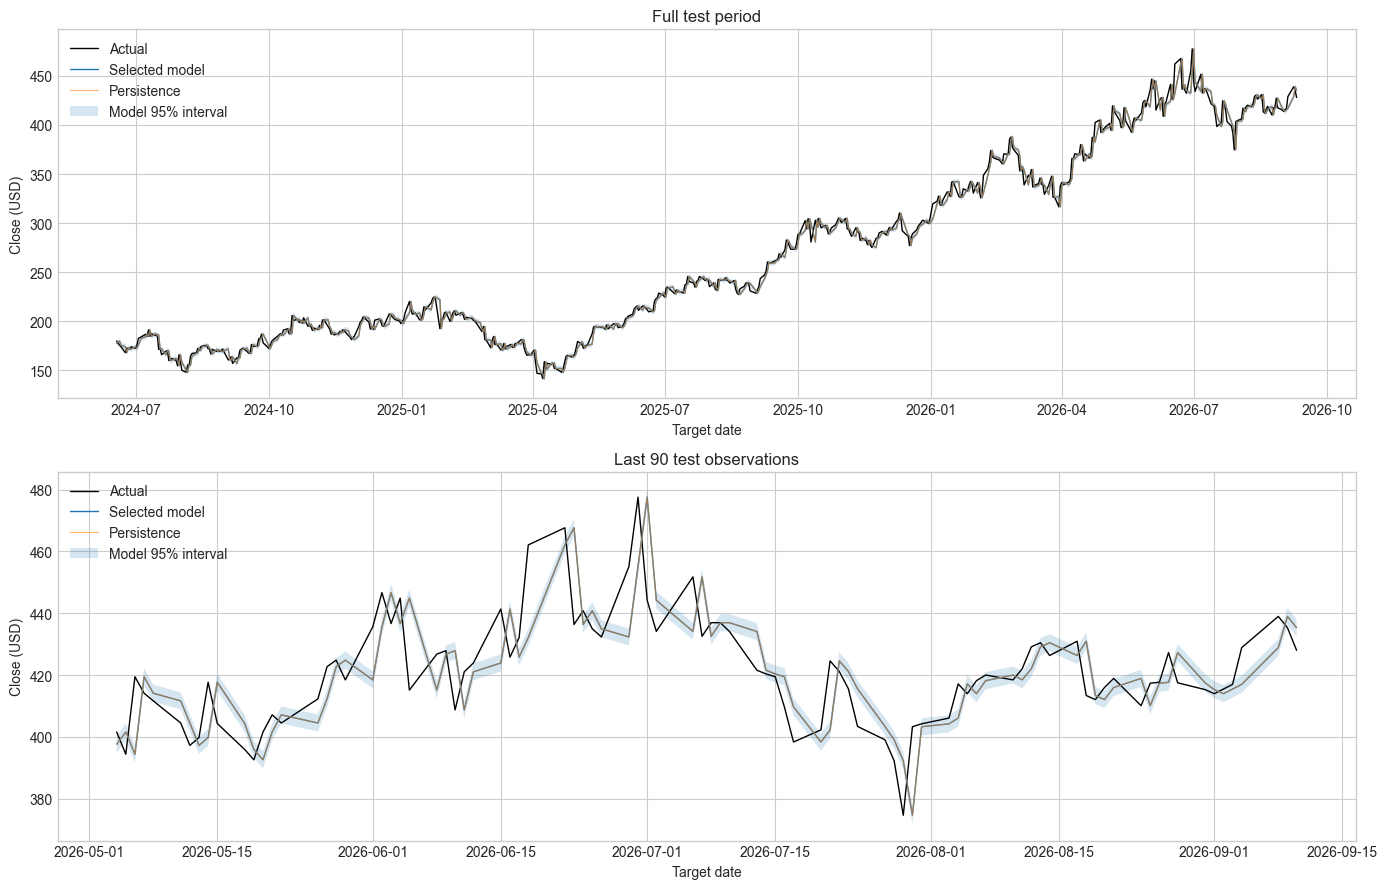

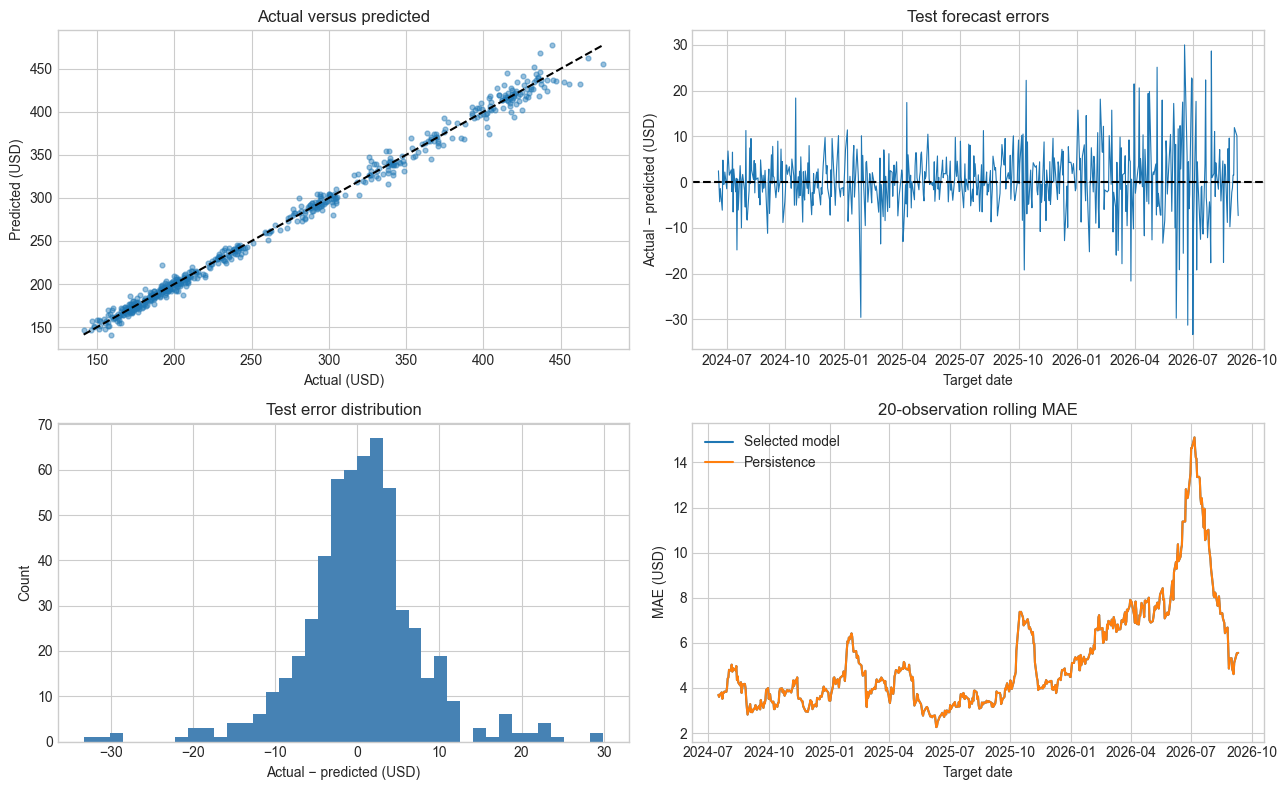

In [9]:
test_predictions, test_lower, test_upper = walk_forward(final_model, test, x_test, intervals=True)
test_metrics = pd.DataFrame({
    BEST_NAME: score(test, test_predictions, history),
    'Persistence': score(test, test['Close'].to_numpy(), history)
}).T
test_metrics.index.name = 'model'
display(test_metrics)
test_metrics.to_csv(RUN_DIR / 'test_metrics.csv')

test_export = test[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].copy()
test_export['Prediction'] = test_predictions
test_export['Persistence'] = test['Close'].to_numpy()
test_export['Lower_95'] = test_lower
test_export['Upper_95'] = test_upper
test_export['Error_actual_minus_predicted'] = test_export['Target_Close'] - test_predictions
test_export['Predicted_return'] = test_predictions / test_export['Close'] - 1
test_export['Actual_return'] = test_export['Target_Close'] / test_export['Close'] - 1
assert (test_lower <= test_upper).all()
assert np.isfinite(test_lower).all() and np.isfinite(test_upper).all()
coverage = float(np.mean((test['Target_Close'].to_numpy() >= test_lower) &
                         (test['Target_Close'].to_numpy() <= test_upper)) * 100)
mean_width = float(np.mean(test_upper - test_lower))
print(f'95% interval empirical coverage: {coverage:.2f}%')
print(f'Mean interval width: ${mean_width:.4f}')
test_export.to_csv(RUN_DIR / 'test_predictions.csv', index=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for ax, frame, title in [(axes[0], test_export, 'Full test period'),
                         (axes[1], test_export.tail(90), 'Last 90 test observations')]:
    ax.plot(frame['Target_Date'], frame['Target_Close'], color='black', label='Actual', linewidth=1)
    ax.plot(frame['Target_Date'], frame['Prediction'], label='Selected model', linewidth=1)
    ax.plot(frame['Target_Date'], frame['Persistence'], label='Persistence', alpha=0.6, linewidth=0.8)
    ax.fill_between(frame['Target_Date'], frame['Lower_95'], frame['Upper_95'],
                    alpha=0.18, label='Model 95% interval')
    ax.set(title=title, xlabel='Target date', ylabel='Close (USD)')
    ax.legend(loc='upper left')
finish_plot('08_test_forecasts')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].scatter(test_export['Target_Close'], test_predictions, alpha=0.45, s=12)
limits = [min(test_export['Target_Close'].min(), test_predictions.min()),
          max(test_export['Target_Close'].max(), test_predictions.max())]
axes[0, 0].plot(limits, limits, '--', color='black')
axes[0, 0].set(title='Actual versus predicted', xlabel='Actual (USD)', ylabel='Predicted (USD)')
axes[0, 1].plot(test_export['Target_Date'], test_export['Error_actual_minus_predicted'], linewidth=0.8)
axes[0, 1].axhline(0, color='black', linestyle='--')
axes[0, 1].set(title='Test forecast errors', xlabel='Target date', ylabel='Actual − predicted (USD)')
axes[1, 0].hist(test_export['Error_actual_minus_predicted'], bins=40, color='steelblue')
axes[1, 0].set(title='Test error distribution', xlabel='Actual − predicted (USD)', ylabel='Count')
for column, label in [('Prediction', 'Selected model'), ('Persistence', 'Persistence')]:
    rolling_mae = (test_export['Target_Close'] - test_export[column]).abs().rolling(20).mean()
    axes[1, 1].plot(test_export['Target_Date'], rolling_mae, label=label)
axes[1, 1].set(title='20-observation rolling MAE', xlabel='Target date', ylabel='MAE (USD)')
axes[1, 1].legend()
finish_plot('09_test_error_analysis')


## 10. Save and reload the selected model

Each run gets a unique folder under `models/arima/`, so previous results are preserved. `selected_model.pkl` contains the locked model fitted on train + validation **before test observation updates**. `preprocessing.joblib` contains the scaler, feature order, and transformation metadata. `manifest.json` records the data hash, package versions, target definition, split dates, candidate grid, selection rule, and diagnostics. Prediction and metric CSVs plus PNG plots accompany the model.

The reload check reproduces the first test forecast using only its origin features. This verifies that saving retains both the fitted parameters/state and the input preprocessing. The saved model's state belongs to its recorded cutoff; before forecasting from a later origin, supply each subsequently observed target and its correctly aligned origin features through `extend`, or refit under a separately documented deployment procedure. Do not pass the newest row directly to an old model state and call it the next-day forecast. Load pickle/joblib artifacts only from trusted sources.


In [10]:
MODEL_FILE = RUN_DIR / 'selected_model.pkl'
PREPROCESSOR_FILE = RUN_DIR / 'preprocessing.joblib'
final_model.save(MODEL_FILE)
preprocessing = {'scaler': final_scaler, 'features': BEST_COLUMNS,
                 'transforms': {'Volume': 'log1p'} if 'Volume' in BEST_COLUMNS else {},
                 'target': 'Next observed trading day unadjusted Close',
                 'forecast_origin': 'After current trading day market close',
                 'last_training_target_date': str(history['Target_Date'].max().date())}
joblib.dump(preprocessing, PREPROCESSOR_FILE)

from statsmodels.tsa.arima.model import ARIMAResults
reloaded_model = ARIMAResults.load(MODEL_FILE)
reloaded_preprocessing = joblib.load(PREPROCESSOR_FILE)
if BEST_COLUMNS:
    reload_x = reloaded_preprocessing['scaler'].transform(
        feature_values(test.iloc[:1], reloaded_preprocessing['features']))
else:
    reload_x = None
reload_prediction = float(np.asarray(reloaded_model.forecast(steps=1, exog=reload_x)).reshape(-1)[0])
np.testing.assert_allclose(reload_prediction, test_predictions[0], rtol=1e-9, atol=1e-9)
print('Saved-model reload check passed.')

manifest = {
    'run_id': RUN_ID, 'source_file': str(DATA_FILE.relative_to(ROOT)),
    'source_sha256': hashlib.sha256(DATA_FILE.read_bytes()).hexdigest(),
    'provenance': 'Master built from local Yahoo Finance data; local Google Finance comparison available.',
    'raw_rows': len(raw), 'raw_columns': len(raw.columns), 'usable_rows': len(data),
    'raw_start': str(raw['Date'].min().date()), 'raw_end': str(raw['Date'].max().date()),
    'target': 'Close[t+1]', 'inputs': 'Features observable after Close[t]',
    'feature_sets': FEATURE_SETS, 'excluded_columns': EXCLUDED,
    'splits': json.loads(split_summary.to_json(orient='records', date_format='iso')),
    'order_grid': ORDER_GRID, 'trend': TREND, 'max_optimizer_iterations': MAX_ITER,
    'protocol': 'Fit once per split origin; one-step forecast then extend state with actual; no parameter refits.',
    'selection': 'Converged validation RMSE, then MAE, then parameter count, then candidate name.',
    'selected_configuration': BEST_NAME, 'selected_order': BEST_ORDER,
    'selected_features': BEST_COLUMNS, 'validation_metrics': {k: float(best[k]) for k in baseline_validation},
    'validation_persistence_metrics': baseline_validation,
    'test_metrics': json.loads(test_metrics.to_json(orient='index')),
    'test_interval_coverage_pct': coverage, 'test_mean_interval_width_usd': mean_width,
    'final_converged': final_converged, 'final_fit_warnings': final_warnings,
    'final_fit_seconds': final_fit_seconds,
    'saved_model_state': 'Train + validation cutoff, before test updates',
    'prior_test_exposure': 'Original project notebooks already evaluated part of this period.',
    'versions': {'python': platform.python_version(), 'numpy': np.__version__,
                 'pandas': pd.__version__, 'scipy': scipy.__version__,
                 'statsmodels': statsmodels.__version__, 'sklearn': sklearn.__version__,
                 'joblib': joblib.__version__},
}
(RUN_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2, allow_nan=False), encoding='utf-8')
(ROOT / 'models' / 'arima' / 'latest_run.json').write_text(
    json.dumps({'run_id': RUN_ID, 'directory': str(RUN_DIR.relative_to(ROOT))}, indent=2), encoding='utf-8')
print('Model and all experiment artifacts saved in:', RUN_DIR)


Saved-model reload check passed.
Model and all experiment artifacts saved in: F:\SEM-7\Time Series Analysis\Project\models\arima\20260923T021526961853Z


## 11. Report-ready interpretation

The generated summary below uses actual results from this execution. It distinguishes validation-based selection from final test performance. Include the complete grid and failed fits in the report rather than showing only favorable candidates. No forecasting metric here establishes profitability; that requires a separate chronological strategy experiment with realistic execution timing and costs.

To adapt this notebook for another model family, preserve the target dates, data-availability rules, baseline, evaluation metrics, and reserved test procedure. Model-specific hyperparameters can differ across families, but the all-feature and curated-feature variants within each family should receive a comparable search budget.


In [11]:
selected_test = test_metrics.loc[BEST_NAME]
baseline_test = test_metrics.loc['Persistence']
validation_verdict = ('beat persistence on validation' if best['RMSE'] < baseline_validation['RMSE']
                      else 'did not beat persistence on validation')
test_verdict = ('beat persistence on the reserved test period' if selected_test['RMSE'] < baseline_test['RMSE']
                else 'did not beat persistence on the reserved test period')
summary = f'''# ARIMA experiment results

- Data: {len(raw):,} source rows, {len(data):,} aligned complete observations; next-trading-day Close in USD.
- Selected configuration: **{BEST_NAME}**, order **{BEST_ORDER}**, {len(BEST_COLUMNS)} exogenous features.
- Selection reason: lowest validation RMSE among converged candidates under the common grid and evaluation protocol.
- Validation: RMSE **${best['RMSE']:.4f}**, MAE **${best['MAE']:.4f}**; persistence RMSE **${baseline_validation['RMSE']:.4f}**. The selected model {validation_verdict}.
- Test: MSE **{selected_test['MSE']:.4f} USD²**, RMSE **${selected_test['RMSE']:.4f}**, MAE **${selected_test['MAE']:.4f}**, MAPE **{selected_test['MAPE_pct']:.3f}%**, R² **{selected_test['R2']:.5f}**.
- Test persistence RMSE: **${baseline_test['RMSE']:.4f}**. The selected model {test_verdict}.
- Test direction accuracy: **{selected_test['Direction_accuracy_pct']:.2f}%**; this is not a profitability metric.
- Test model-interval coverage: **{coverage:.2f}%** for nominal 95% intervals.
- Eligible candidates: **{len(eligible)} / {len(results)}**. Review warnings and design collinearity before interpreting coefficients.
- Limitations: single historical validation window, fixed coefficients within each evaluation period, possible regime changes, conditional Gaussian intervals, and prior project exposure to part of the test period. Small RMSE differences are not evidence of statistical significance.
- Profitability evaluation is deferred. This experiment makes no claim that the selected forecasting model maximizes profit.
'''
display(Markdown(summary))
(RUN_DIR / 'summary.md').write_text(summary, encoding='utf-8')


# ARIMA experiment results

- Data: 3,771 source rows, 3,721 aligned complete observations; next-trading-day Close in USD.
- Selected configuration: **ARIMA_close_only**, order **(0, 1, 0)**, 0 exogenous features.
- Selection reason: lowest validation RMSE among converged candidates under the common grid and evaluation protocol.
- Validation: RMSE **$2.2317**, MAE **$1.6072**; persistence RMSE **$2.2317**. The selected model did not beat persistence on validation.
- Test: MSE **54.7788 USD²**, RMSE **$7.4013**, MAE **$5.2326**, MAPE **1.968%**, R² **0.99349**.
- Test persistence RMSE: **$7.4013**. The selected model did not beat persistence on the reserved test period.
- Test direction accuracy: **0.18%**; this is not a profitability metric.
- Test model-interval coverage: **40.79%** for nominal 95% intervals.
- Eligible candidates: **18 / 24**. Review warnings and design collinearity before interpreting coefficients.
- Limitations: single historical validation window, fixed coefficients within each evaluation period, possible regime changes, conditional Gaussian intervals, and prior project exposure to part of the test period. Small RMSE differences are not evidence of statistical significance.
- Profitability evaluation is deferred. This experiment makes no claim that the selected forecasting model maximizes profit.


1340